# Install libraries

In [89]:
%pip install pillow
%pip install scikit-learn
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
%pip install tqdm
%pip install matplotlib
%pip install tensorboard
%pip install imagehash pillow
%pip install thop

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Setup
**Note:** Always run this first to setup variables

In [33]:
import os

PROJECT_ROOT = "."
os.makedirs(PROJECT_ROOT, exist_ok=True)

# ISIC 2018
METADATA_CSV_PATH = os.path.join(PROJECT_ROOT, "isic_2018_dataset/challenge-2018-task-3-training_metadata_2026-04-08.csv")
IMAGES_FOLDER_PATH = os.path.join(PROJECT_ROOT, "isic_2018_dataset/ISIC-images")

# ISIC 2019
ADDITIONAL_METADATA_CSV_PATH = os.path.join(PROJECT_ROOT, "isic_2019_dataset/challenge-2019-training_metadata_2026-04-09.csv")
ADDITIONAL_IMAGES_FOLDER_PATH = os.path.join(PROJECT_ROOT, "isic_2019_dataset/ISIC-images")

AUGMENTED_IMAGES_FOLDER_PATH = os.path.join(PROJECT_ROOT, "augmented dataset/train-image")
MODELS_FOLDER_PATH = os.path.join(PROJECT_ROOT, "models")

os.makedirs(AUGMENTED_IMAGES_FOLDER_PATH, exist_ok=True)
os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)

In [34]:
MINORITY_TARGET_LABEL = 1 # malignant label

# Balance minority class by adding samples from ISIC 2019 dataset. If false, class balancing is performed by using augmented dataset instead
COMBINE_FROM_ISIC_2019_DATASET = True 

CREATE_AUGMENTED_FOLDER = False # set this to false if augmented dataset is already created
AUGMENT_NUMBER = 5 # how many augmented copies for each image sample

PERFORM_HYPERPARAMETER_TUNING = False

if COMBINE_FROM_ISIC_2019_DATASET:
    TENSORBOARD_LOGS = "logs_combined_dataset"
else:
    TENSORBOARD_LOGS = "logs_base_dataset"

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

# Load Dataset

In [10]:
import csv

def print_csv_unique_values(path):
    diag1_set = set()
    diag2_set = set()

    with open(path, newline="") as f:
        print(f"From {path}:")
        reader = csv.DictReader(f)

        for row in reader:
            d1 = (row.get("diagnosis_1") or "").strip()
            d2 = (row.get("diagnosis_2") or "").strip()

            if d1:
                diag1_set.add(d1)
            if d2:
                diag2_set.add(d2)

    print("Unique values in diagnosis_1:")
    for val in sorted(diag1_set):
        print(val)

    print("\nUnique values in diagnosis_2:")
    for val in sorted(diag2_set):
        print(val)

print_csv_unique_values(METADATA_CSV_PATH)
print()
print_csv_unique_values(ADDITIONAL_METADATA_CSV_PATH)

From .\isic_2018_dataset/challenge-2018-task-3-training_metadata_2026-04-08.csv:
Unique values in diagnosis_1:
Benign
Indeterminate
Malignant

Unique values in diagnosis_2:
Benign epidermal proliferations
Benign melanocytic proliferations
Benign soft tissue proliferations - Fibro-histiocytic
Benign soft tissue proliferations - Vascular
Indeterminate epidermal proliferations
Malignant adnexal epithelial proliferations - Follicular
Malignant epidermal proliferations
Malignant melanocytic proliferations (Melanoma)

From .\isic_2019_dataset/challenge-2019-training_metadata_2026-04-09.csv:
Unique values in diagnosis_1:
Benign
Indeterminate
Malignant

Unique values in diagnosis_2:
Benign epidermal proliferations
Benign melanocytic proliferations
Benign soft tissue proliferations - Fibro-histiocytic
Benign soft tissue proliferations - Vascular
Collision - Only benign proliferations
Indeterminate epidermal proliferations
Indeterminate melanocytic proliferations
Malignant adnexal epithelial pro

In [11]:
def read_csv_metadata(csv_dict, path):
    with open(path, newline="") as f:
        reader = csv.DictReader(f)

        skipped = 0
        filtered_out = 0

        for row in reader:
            diagnosis1 = row["diagnosis_1"].strip().lower()
            diagnosis2 = row["diagnosis_2"].strip().lower()

            # only keep rows where diagnosis_2 contains "melano"
            if "melano" not in diagnosis2:
                filtered_out += 1
                continue

            if diagnosis1 == "benign":
                csv_dict[row["isic_id"]] = 0
            elif diagnosis1 == "malignant":
                csv_dict[row["isic_id"]] = 1
            else:
                skipped += 1

        print(f"Skipped {skipped} indeterminate samples")
        print(f"Filtered out (no 'melano'): {filtered_out}")

    print("Total length:", len(csv_dict))

    target_counts = {}
    for target in csv_dict.values():
        target_counts[target] = target_counts.get(target, 0) + 1

    for target, count in target_counts.items():
        print(f"target {target}: {count}")

csv_dict = {}
read_csv_metadata(csv_dict=csv_dict, path=METADATA_CSV_PATH)

Skipped 0 indeterminate samples
Filtered out (no 'melano'): 2197
Total length: 7818
target 0: 6705
target 1: 1113


In [12]:
import os
import numpy as np

def load_image_paths_list(folder_path):
    image_file_paths = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith(".jpg")
    ]

    return image_file_paths

def load_dataset(image_paths: list[str], csv_metadata: dict) -> tuple[list[str], np.ndarray]:
    valid_paths = []
    labels = []

    for path in image_paths:
        image_id = os.path.splitext(os.path.basename(path))[0]

        if image_id not in csv_metadata:
            continue

        valid_paths.append(path)
        labels.append(csv_metadata[image_id])
    
    return valid_paths, labels

image_file_paths = load_image_paths_list(IMAGES_FOLDER_PATH)
image_paths, labels = load_dataset(image_file_paths, csv_dict)

print(len(image_paths))
print(len(labels))

7052
7052


In [13]:
from collections import Counter

label_counts = Counter(labels)

for label, count in label_counts.items():
    print(f"{label}: {count}")

0: 6158
1: 894


In [14]:
if COMBINE_FROM_ISIC_2019_DATASET:
    additional_csv_dict = {}
    read_csv_metadata(additional_csv_dict, ADDITIONAL_METADATA_CSV_PATH)

    #remove non-minority samples
    additional_csv_dict = {
        k: v for k, v in additional_csv_dict.items()
        if v == MINORITY_TARGET_LABEL
    }

    print("\nAfter filtering out non-minority label")
    target_counts = {}
    for target in additional_csv_dict.values():
        target_counts[target] = target_counts.get(target, 0) + 1

    for target, count in target_counts.items():
        print(f"target {target}: {count}")
    
    print()
    additional_image_file_paths = load_image_paths_list(ADDITIONAL_IMAGES_FOLDER_PATH)
    additional_image_paths, additional_labels = load_dataset(additional_image_file_paths, additional_csv_dict)

    image_paths += additional_image_paths
    labels += additional_labels

    print(len(image_paths))
    print(len(labels))


Skipped 1 indeterminate samples
Filtered out (no 'melano'): 7937
Total length: 17393
target 0: 12871
target 1: 4522

After filtering out non-minority label
target 1: 4522

11574
11574


In [15]:
from PIL import Image
import imagehash
from tqdm import tqdm

def compute_hash(image_path, hash_size=8):
    img = Image.open(image_path)
    return imagehash.phash(img, hash_size=hash_size)

def remove_duplicate_from_list(image_paths, labels, threshold=1):
    if (len(image_paths) != len(labels)):
        print("Image paths and labels is not the same length")
        return image_paths, labels

    hashes = []

    print("Computing image hashes...")
    for path in tqdm(image_paths):
        try:
            h = compute_hash(path)
            hashes.append((path, h))
        except Exception as e:
            print(f"Skipping {path}: {e}")

    print("\nRemoving duplicates...")

    kept_paths = []
    kept_labels = []

    removed = set()

    total_pairs = len(hashes) * (len(hashes) - 1) // 2
    pbar = tqdm(total=total_pairs)

    for i in range(len(hashes)):
        path1, hash1 = hashes[i]

        if path1 in removed:
            pbar.update(len(hashes) - i - 1)
            continue

        kept_paths.append(path1)
        kept_labels.append(labels[i])  # keep label aligned

        for j in range(i + 1, len(hashes)):
            path2, hash2 = hashes[j]

            distance = hash1 - hash2

            if distance <= threshold:
                removed.add(path2)

            pbar.update(1)

    pbar.close()

    print(f"Kept: {len(kept_paths)} images")
    print(f"Removed (duplicates): {len(removed)} images")

    return kept_paths, kept_labels

#make sure no duplicate images between ISIC 2018 and ISIC 2019
if (COMBINE_FROM_ISIC_2019_DATASET):
    image_paths, labels = remove_duplicate_from_list(image_paths=image_paths, labels=labels)

Computing image hashes...


100%|██████████| 11574/11574 [01:39<00:00, 116.19it/s]



Removing duplicates...


100%|██████████| 66972951/66972951 [08:23<00:00, 133098.35it/s] 

Kept: 10646 images
Removed (duplicates): 928 images


In [16]:
from collections import Counter

label_counts = Counter(labels)

for label, count in label_counts.items():
    print(f"{label}: {count}")

0: 6142
1: 4504


In [17]:
from sklearn.model_selection import train_test_split

path_train, path_test, y_train, y_test = train_test_split(image_paths, labels, test_size=0.2, stratify=labels, random_state=42)
path_train, path_val, y_train, y_val = train_test_split(path_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

print("Train paths:", len(path_train))
print("Train labels:", len(y_train))

print("Validation paths:", len(path_val))
print("Validation labels:", len(y_val))

print("Test paths:", len(path_test))
print("Test labels:", len(y_test))

Train paths: 6387
Train labels: 6387
Validation paths: 2129
Validation labels: 2129
Test paths: 2130
Test labels: 2130


In [18]:
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import shutil

augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(size=IMAGE_SIZE, scale=(0.8,1.0)),
])

augmented_paths = []
augmented_labels = []

if (COMBINE_FROM_ISIC_2019_DATASET == True):
    print("Do nothing (class is balanced from adding ISIC 2019 minority samples)")
    pass
elif (CREATE_AUGMENTED_FOLDER == True):
    if os.path.exists(AUGMENTED_IMAGES_FOLDER_PATH):
        shutil.rmtree(AUGMENTED_IMAGES_FOLDER_PATH)

    os.makedirs(AUGMENTED_IMAGES_FOLDER_PATH, exist_ok=True)
    for label in set(y_train):
        os.makedirs(os.path.join(AUGMENTED_IMAGES_FOLDER_PATH, str(label)), exist_ok=True)

    print("Pre-augmenting minority class images and saving to disk...")
    for image_path, label in tqdm(zip(path_train, y_train), total=len(y_train)):
        image = Image.open(image_path).convert("RGB")
        
        # Destination folder
        dest_folder = os.path.join(AUGMENTED_IMAGES_FOLDER_PATH, str(label))
        
        # Save original image
        base_name = os.path.basename(image_path)
        save_path = os.path.join(dest_folder, base_name)
        resized_img = image.resize(IMAGE_SIZE)
        resized_img.save(save_path)

        augmented_paths.append(save_path)
        augmented_labels.append(label)
        
        # # If minority, generate extra augmented copies
        if label == MINORITY_TARGET_LABEL:
            for i in range(AUGMENT_NUMBER):
                aug_img = augment_transform(image)
                aug_name = f"{os.path.splitext(base_name)[0]}_aug{i}.jpg"
                aug_path = os.path.join(dest_folder, aug_name)
                aug_img.save(aug_path)

                augmented_paths.append(aug_path)
                augmented_labels.append(label)

else:
    # if folder exists, read all images from augmented folder
    print("Loading augmented images from disk...")
    for label in os.listdir(AUGMENTED_IMAGES_FOLDER_PATH):
        label_folder = os.path.join(AUGMENTED_IMAGES_FOLDER_PATH, label)
        if not os.path.isdir(label_folder):
            continue
        for file_name in os.listdir(label_folder):
            file_path = os.path.join(label_folder, file_name)
            if file_path.lower().endswith((".jpg")):
                augmented_paths.append(file_path)
                augmented_labels.append(int(label))

if (COMBINE_FROM_ISIC_2019_DATASET == False):
    # Update training lists
    path_train = augmented_paths
    y_train = np.array(augmented_labels)

    print("Train paths:", len(path_train))
    print("Train labels:", y_train.shape)

    y_array = np.array(y_train)
    unique, counts = np.unique(y_array, return_counts=True)
    print("\nClass distribution in training set:")
    for label, count in zip(unique, counts):
        print(f"Class {label}: {count} samples")

Do nothing (class is balanced from adding ISIC 2019 minority samples)


In [19]:
print("Train paths:", len(path_train))
print("Train labels:", len(y_train)) 

print("Validation paths:", len(path_val))
print("Validation labels:", len(y_val))

print("Test paths:", len(path_test))
print("Test labels:", len(y_test))

Train paths: 6387
Train labels: 6387
Validation paths: 2129
Validation labels: 2129
Test paths: 2130
Test labels: 2130


In [20]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch

class ImageDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(self.labels[idx])
        return image, label

In [21]:
from torchvision import transforms

# transform for all images
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(ImageDataset(path_train, y_train, transform=transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(ImageDataset(path_val, y_val, transform=transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(ImageDataset(path_test, y_test, transform=transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

# Training Function

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

class MetricsEvaluator:
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def compute(self, labels, probs):
        labels = np.array(labels)
        probs = np.array(probs)
        
        preds = (probs >= self.threshold).astype(int)

        return {
            "accuracy": accuracy_score(labels, preds),
            "precision": precision_score(labels, preds, zero_division=0),
            "recall": recall_score(labels, preds, zero_division=0),
            "f1": f1_score(labels, preds, zero_division=0),
            "auc": roc_auc_score(labels, probs)
        }
    
    def print(self, metrics, prefix=""):
        print(
            f"{prefix} Acc: {metrics['accuracy']:.4f} | "
            f"Precision: {metrics['precision']:.4f} | "
            f"Recall: {metrics['recall']:.4f} | "
            f"F1: {metrics['f1']:.4f} | "
            f"AUC: {metrics['auc']:.4f}"
        )

In [44]:
import matplotlib.pyplot as plt

def plot_training_loss_and_accuracy(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = list(range(1, len(train_losses) + 1))

    plt.figure(figsize=(10,4))

    # Loss plot
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.xticks(epochs)  # force integer ticks
    plt.legend()

    # Accuracy plot
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.xticks(epochs)  # force integer ticks
    plt.legend()

    plt.tight_layout()
    plt.show()


In [54]:
import torch.nn as nn 
import torch.optim as optim 
from torchvision import models 

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def Train_Model(model, train_loader, val_loader, epochs, loss_function, optimizer, 
                device, best_model_path, threshold=0.5, patience=10, plot_graph=False):
    
    best_loss = float('inf')
    best_epoch = -1
    patience_counter = 0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    train_metrics_history, val_metrics_history = [], []

    best_train_metrics = None
    best_val_metrics = None

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        # -------------------------
        # Training
        # -------------------------
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        loop = tqdm(train_loader)

        all_train_labels = []
        all_train_probs = []

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)

            total += labels.size(0)

            # store for metrics
            all_train_labels.extend(labels.cpu().numpy())
            all_train_probs.extend(probs[:, 1].detach().cpu().numpy())

            loop.set_postfix(loss=f"{running_loss/total:.4f}")

        # Final loss
        train_loss = running_loss / total
        train_losses.append(train_loss)

        evaluator = MetricsEvaluator(threshold=threshold)
        train_metrics = evaluator.compute(all_train_labels, all_train_probs)
        train_metrics_history.append(train_metrics)

        train_acc = train_metrics["accuracy"]
        train_accuracies.append(train_acc)

        print(f"Train Loss: {train_loss:.4f}")
        evaluator.print(train_metrics, prefix="Train")

        # -------------------------
        # Validation
        # -------------------------
        model.eval()
        val_loss = 0.0
        all_labels, all_probs = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = loss_function(outputs, labels)
                val_loss += loss.item() * images.size(0)

                probs = torch.softmax(outputs, dim=1)
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs[:,1].cpu().numpy())  # probability for positive class

        val_loss /= len(all_labels)
        val_losses.append(val_loss)

        # Compute metrics
        val_metrics = evaluator.compute(all_labels, all_probs)
        val_metrics_history.append(val_metrics)

        val_acc = val_metrics["accuracy"]
        val_accuracies.append(val_acc)

        print(f"Val Loss: {val_loss:.4f}")
        evaluator.print(val_metrics, prefix="Val")

        # -------------------------
        # Early stopping & save best
        # -------------------------
        if val_loss < best_loss:
            best_loss = val_loss
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),

                'train_losses': train_losses,
                'val_losses': val_losses,

                'train_accuracies' : train_accuracies,
                'val_accuracies' : val_accuracies,

                'train_metrics_history': train_metrics_history,
                'val_metrics_history': val_metrics_history
            }, best_model_path)

            # Save metrics of the best model
            best_train_metrics = train_metrics
            best_val_metrics = val_metrics

            print(f"New best model saved! Epoch {best_epoch}")
        else:
            patience_counter += 1
            print(f"No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    print(f"\nTraining completed. Best Epoch: {best_epoch}")
    if(plot_graph):
        plot_training_loss_and_accuracy(train_losses=train_losses, val_losses=val_losses,
                                         train_accuracies=train_accuracies, val_accuracies=val_accuracies)
    

In [46]:
def log_metrics_to_tensorboard(writer, hparams, model_path):
    # Load the model's metrics
    checkpoint = torch.load(model_path)
    val_metrics = checkpoint.get('val_metrics_history', [None])[-1]

    metric_to_log = {
        'accuracy': val_metrics['accuracy'],
        'precision': val_metrics['precision'],
        'recall': val_metrics['recall'],
        'f1': val_metrics['f1']
    }

    writer.add_hparams(hparams, metric_to_log)

# Train ResNet 50

In [ ]:
import itertools
from torch.utils.tensorboard import SummaryWriter
import os

if PERFORM_HYPERPARAMETER_TUNING:
    os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)
    best_model_path = os.path.join(MODELS_FOLDER_PATH, "resnet50_melanoma.pth")

    # Hyperparameter ranges
    learning_rates = [1e-5]
    optimizers_list = ["SGD"]
    train_layer_config = [
        "layer_3_4_fc",
        # "fc_only",
        # "all"
    ]

    writer = SummaryWriter(log_dir=TENSORBOARD_LOGS)

    for lr, opt_name, trained_layer in itertools.product(learning_rates, optimizers_list, train_layer_config):
        # Initialize model
        model = models.resnet50(weights='DEFAULT')
        model.fc = nn.Linear(model.fc.in_features, 2)

        for param in model.parameters():
            param.requires_grad = False

        if trained_layer == "layer_3_4_fc":
            for name, param in model.named_parameters():
                if "layer3" in name or "layer4" in name or "fc" in name:
                    param.requires_grad = True

        elif trained_layer == "fc_only":
            for param in model.fc.parameters():
                param.requires_grad = True

        elif trained_layer == "all":
            for param in model.parameters():
                param.requires_grad = True

        else:
            raise ValueError(f"Unknown config: {trained_layer}")

        model = model.to(device)

        # Select optimizer
        trainable_params = filter(lambda p: p.requires_grad, model.parameters())

        if opt_name == "SGD":
            optimizer = torch.optim.SGD(
                trainable_params,
                lr=lr,
                momentum=0.9,
                weight_decay=1e-4
            )
        elif opt_name == "Adam":
            optimizer = torch.optim.Adam(
                trainable_params,
                lr=lr,
                weight_decay=1e-4
            )

        # Train model
        Train_Model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=100,
            loss_function=nn.CrossEntropyLoss(),
            optimizer=optimizer,
            device=device,
            best_model_path=best_model_path,
        )

        # Log hyperparameters
        hparams = {
            'model': 'ResNet-50',
            'learning_rate': lr,
            'optimizer': opt_name,
            'trained layer' : trained_layer,
            'batch_size': BATCH_SIZE
        }

        log_metrics_to_tensorboard(writer, hparams, best_model_path)

    writer.close()


Epoch 1/100


100%|██████████| 200/200 [02:28<00:00,  1.34it/s, loss=0.2450]


Train Loss: 0.2450
Train Acc: 0.8946 | Precision: 0.9018 | Recall: 0.8427 | F1: 0.8712 | AUC: 0.9632
Val Loss: 0.1868
Val Acc: 0.9206 | Precision: 0.9507 | Recall: 0.8568 | F1: 0.9013 | AUC: 0.9784
New best model saved! Epoch 1

Epoch 2/100


100%|██████████| 200/200 [02:25<00:00,  1.37it/s, loss=0.1213]


Train Loss: 0.1213
Train Acc: 0.9516 | Precision: 0.9493 | Recall: 0.9356 | F1: 0.9424 | AUC: 0.9908
Val Loss: 0.1890
Val Acc: 0.9244 | Precision: 0.8838 | Recall: 0.9456 | F1: 0.9137 | AUC: 0.9827
No improvement (1/10)

Epoch 3/100


...

Train Loss: 0.0121
Train Acc: 0.9955 | Precision: 0.9948 | Recall: 0.9944 | F1: 0.9946 | AUC: 0.9999
Val Loss: 0.2999
Val Acc: 0.9394 | Precision: 0.9606 | Recall: 0.8935 | F1: 0.9258 | AUC: 0.9772
No improvement (8/10)

Epoch 10/100


100%|██████████| 200/200 [02:25<00:00,  1.38it/s, loss=0.0182]


Train Loss: 0.0182
Train Acc: 0.9937 | Precision: 0.9933 | Recall: 0.9919 | F1: 0.9926 | AUC: 0.9996
Val Loss: 0.2516
Val Acc: 0.9305 | Precision: 0.9160 | Recall: 0.9201 | F1: 0.9181 | AUC: 0.9807
No improvement (9/10)

Epoch 11/100


100%|██████████| 200/200 [02:30<00:00,  1.33it/s, loss=0.0136]


Train Loss: 0.0136
Train Acc: 0.9951 | Precision: 0.9952 | Recall: 0.9933 | F1: 0.9943 | AUC: 0.9999
Val Loss: 0.2866
Val Acc: 0.9281 | Precision: 0.9074 | Recall: 0.9245 | F1: 0.9159 | AUC: 0.9775
No improvement (10/10)
Early stopping triggered

Training completed. Best Epoch: 1


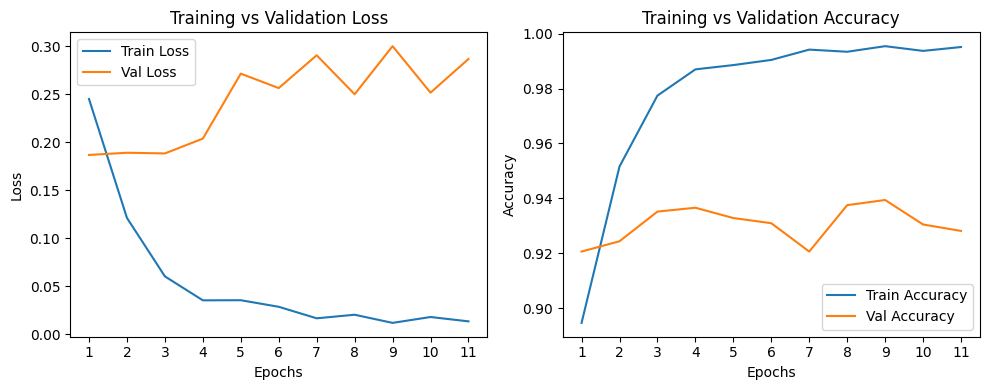

In [55]:
import os

os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)
best_model_path = os.path.join(MODELS_FOLDER_PATH, "resnet50_melanoma_final.pth")

model = models.resnet50(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, 2)

# Train all layers
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

model = model.to(device)

# Train the model
Train_Model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    loss_function=nn.CrossEntropyLoss(),
    optimizer=optimizer,
    device=device,
    best_model_path=best_model_path,
    plot_graph=True
)

# Train ResNet 18

In [ ]:
import itertools
from torch.utils.tensorboard import SummaryWriter
import os

if PERFORM_HYPERPARAMETER_TUNING:
    os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)
    best_model_path = os.path.join(MODELS_FOLDER_PATH, "resnet18_melanoma.pth")

    # Hyperparameter ranges
    learning_rates = [1e-5]
    optimizers_list = ["Adam"]
    train_layer_config = [
        # "layer_3_4_fc",
        "fc_only",
        "all"
    ]

    writer = SummaryWriter(log_dir=TENSORBOARD_LOGS)

    for lr, opt_name, trained_layer in itertools.product(learning_rates, optimizers_list, train_layer_config):
        # Initialize model
        model = models.resnet18(weights='DEFAULT')
        model.fc = nn.Linear(model.fc.in_features, 2)

        for param in model.parameters():
            param.requires_grad = False

        if trained_layer == "layer_3_4_fc":
            for name, param in model.named_parameters():
                if "layer3" in name or "layer4" in name or "fc" in name:
                    param.requires_grad = True

        elif trained_layer == "fc_only":
            for param in model.fc.parameters():
                param.requires_grad = True

        elif trained_layer == "all":
            for param in model.parameters():
                param.requires_grad = True

        else:
            raise ValueError(f"Unknown config: {trained_layer}")

        model = model.to(device)

        # Select optimizer
        trainable_params = filter(lambda p: p.requires_grad, model.parameters())

        if opt_name == "SGD":
            optimizer = torch.optim.SGD(
                trainable_params,
                lr=lr,
                momentum=0.9,
                weight_decay=1e-4
            )
        elif opt_name == "Adam":
            optimizer = torch.optim.Adam(
                trainable_params,
                lr=lr,
                weight_decay=1e-4
            )

        # Train model
        Train_Model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=100,
            loss_function=nn.CrossEntropyLoss(),
            optimizer=optimizer,
            device=device,
            best_model_path=best_model_path,
        )

        # Log hyperparameters
        hparams = {
            'model': 'ResNet-18',
            'learning_rate': lr,
            'optimizer': opt_name,
            'trained layer' : trained_layer,
            'batch_size': BATCH_SIZE
        }

        log_metrics_to_tensorboard(writer, hparams, best_model_path)

    writer.close()


Epoch 1/100


100%|██████████| 200/200 [01:50<00:00,  1.81it/s, loss=0.3007]


Train Loss: 0.3007
Train Acc: 0.8638 | Precision: 0.8385 | Recall: 0.8397 | F1: 0.8391 | AUC: 0.9453
Val Loss: 0.2314
Val Acc: 0.9004 | Precision: 0.8992 | Recall: 0.8613 | F1: 0.8798 | AUC: 0.9654
New best model saved! Epoch 1

Epoch 2/100


100%|██████████| 200/200 [01:46<00:00,  1.88it/s, loss=0.1938]


Train Loss: 0.1938
Train Acc: 0.9178 | Precision: 0.9175 | Recall: 0.8853 | F1: 0.9011 | AUC: 0.9773
Val Loss: 0.2024
Val Acc: 0.9126 | Precision: 0.9191 | Recall: 0.8701 | F1: 0.8940 | AUC: 0.9728
New best model saved! Epoch 2

Epoch 3/100


...

Train Loss: 0.0077
Train Acc: 0.9992 | Precision: 0.9996 | Recall: 0.9985 | F1: 0.9991 | AUC: 1.0000
Val Loss: 0.2308
Val Acc: 0.9248 | Precision: 0.9244 | Recall: 0.8957 | F1: 0.9098 | AUC: 0.9792
No improvement (8/10)

Epoch 13/100


100%|██████████| 200/200 [01:43<00:00,  1.92it/s, loss=0.0064]


Train Loss: 0.0064
Train Acc: 0.9997 | Precision: 1.0000 | Recall: 0.9993 | F1: 0.9996 | AUC: 1.0000
Val Loss: 0.2373
Val Acc: 0.9263 | Precision: 0.9439 | Recall: 0.8779 | F1: 0.9097 | AUC: 0.9788
No improvement (9/10)

Epoch 14/100


100%|██████████| 200/200 [01:45<00:00,  1.90it/s, loss=0.0043]


Train Loss: 0.0043
Train Acc: 0.9998 | Precision: 1.0000 | Recall: 0.9996 | F1: 0.9998 | AUC: 1.0000
Val Loss: 0.2482
Val Acc: 0.9267 | Precision: 0.9419 | Recall: 0.8812 | F1: 0.9106 | AUC: 0.9791
No improvement (10/10)
Early stopping triggered

Training completed. Best Epoch: 4


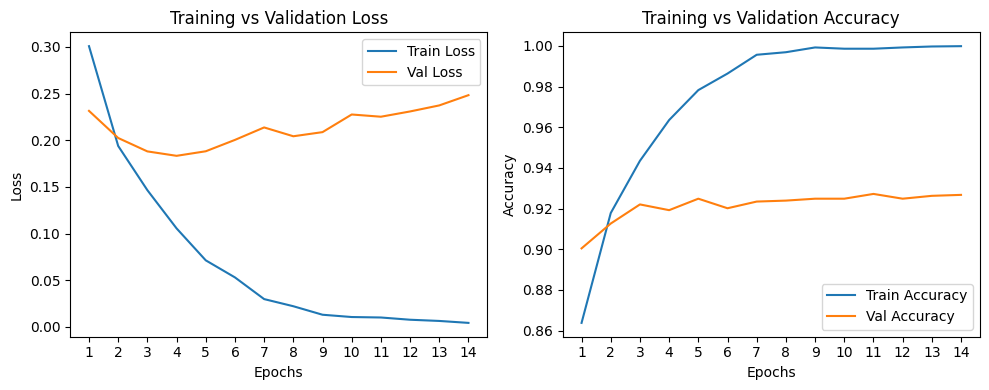

In [56]:
import os

os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)
best_model_path = os.path.join(MODELS_FOLDER_PATH, "resnet18_melanoma_final.pth")

model = models.resnet18(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, 2)

# Train all layers
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

model = model.to(device)

# Train the model
Train_Model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    loss_function=nn.CrossEntropyLoss(),
    optimizer=optimizer,
    device=device,
    best_model_path=best_model_path,
    plot_graph=True
)

# Test Model
**Note:** Must run Load Dataset first

In [24]:
import torch
import numpy as np
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

def plot_precision_recall_curve(model, val_loader, device, target_recall):
    model.eval()
    
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # class 1 probability
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # Compute precision-recall curve
    precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)

    # Plot curve
    plt.figure(figsize=(3, 3))
    plt.plot(recalls, precisions, color='blue')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.grid(True)

    # Find threshold for target recall
    idxs = np.where(recalls >= target_recall)[0]
    if len(idxs) > 0:
        best_idx = idxs[-1]  # last index where recall ≥ target
        best_threshold = thresholds[best_idx]
    else:
        best_threshold = None
        print(f"No threshold achieves recall ≥ {target_recall}")

    plt.show()

    return best_threshold


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from thop import profile
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import models

import pandas as pd
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def Test_Model(model, test_loader, threshold=0.5, show_efficiency=False, show_samples=False):

    torch.cuda.empty_cache()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []
    all_images = []

    start_time = time.time() 

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:,1].cpu().numpy())
            all_images.extend(images.cpu())  # keep raw images for visualization

    print(f"Prediction threshold: {threshold}\n")
    all_preds = (np.array(all_probs) >= threshold).astype(int)

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='binary')
    rec = recall_score(all_labels, all_preds, average='binary')
    f1 = f1_score(all_labels, all_preds, average='binary')
    auroc = roc_auc_score(all_labels, all_probs)

    cm = confusion_matrix(all_labels, all_preds)
    labels_txt = ["Benign (0)", "Malignant (1)"]
    cm_df = pd.DataFrame(cm, index=[f"True {l}" for l in labels_txt],
                        columns=[f"Pred {l}" for l in labels_txt])

    print(f"Accuracy:  {acc:.5f}")
    print(f"Precision: {prec:.5f}")
    print(f"Recall:    {rec:.5f}")
    print(f"F1-score:  {f1:.5f}")
    print(f"ROC AUC:   {auroc:.5f}")
    display(cm_df)

    total_time = time.time() - start_time
    avg_time_per_image = total_time / len(all_images)
    throughput = len(all_images) / total_time
    
    if (show_efficiency):
        print("\n=== Model Efficiency ===")
        print(f"Inference time for {len(all_images)} images: {total_time:.2f} s")
        print(f"Average time per image: {avg_time_per_image*1000:.2f} ms")
        print(f"Throughput: {throughput:.2f} images/sec\n")

        total_params = sum(p.numel() for p in model.parameters())
        print(f"Total parameters: {total_params:,}")
        print(f"Model size: {total_params * 4 / (1024**2):.2f} MB")

        if torch.cuda.is_available():
            print(f"Peak GPU memory: {torch.cuda.max_memory_allocated() / 1024**2:.2f} MB")

        flops, _ = get_flops(model, device)
        print(f"FLOPs: {flops / 1e9:.2f} GFLOPs")

    if show_samples:
        categories = {"TP": [], "TN": [], "FP": [], "FN": []}
        for img, true, pred, prob in zip(all_images, all_labels, all_preds, all_probs):
            if true == 1 and pred == 1:
                categories["TP"].append((img, prob))
            elif true == 0 and pred == 0:
                categories["TN"].append((img, prob))
            elif true == 0 and pred == 1:
                categories["FP"].append((img, prob))
            elif true == 1 and pred == 0:
                categories["FN"].append((img, prob))

        for cat, items in categories.items():
            n = min(5, len(items))
            if n > 0:
                fig, axes = plt.subplots(1, n, figsize=(1*n, 1))
                fig.suptitle(cat, fontsize=14)

                for i in range(n):
                    img, prob = items[i]
                    axes[i].imshow(unnormalize(img))
                    axes[i].set_xlabel(f"{prob:.2f}", fontsize=10)
                    axes[i].xaxis.set_label_position('bottom')

                    axes[i].set_xticks([])
                    axes[i].set_yticks([])

                plt.show()

    torch.cuda.empty_cache()

def get_flops(model, device):
    model.eval()
    images, _ = next(iter(test_loader))
    dummy_input = images[:1].to(device)

    flops, params = profile(model, inputs=(dummy_input,), verbose=False)

    return flops, params

def unnormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean   # reverse normalization
    img = np.clip(img, 0, 1) # clip to valid range
    return img



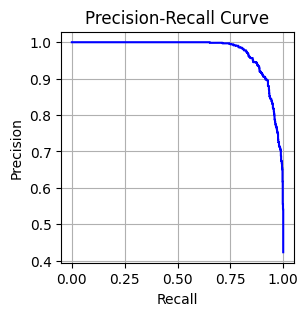

Testing: 100%|██████████| 67/67 [00:28<00:00,  2.35it/s]

Prediction threshold: 0.17190226912498474

Accuracy:  0.91033
Precision: 0.84804
Recall:    0.96004
F1-score:  0.90057
ROC AUC:   0.98211


,Pred Benign (0),Pred Malignant (1)
True Benign (0),1074,155
True Malignant (1),36,865



=== Model Efficiency ===
Inference time for 2130 images: 28.50 s
Average time per image: 13.38 ms
Throughput: 74.75 images/sec

Total parameters: 23,512,130
Model size: 89.69 MB
Peak GPU memory: 814.38 MB
FLOPs: 4.13 GFLOPs


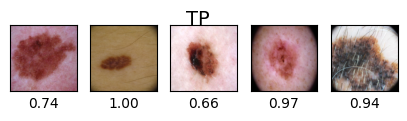

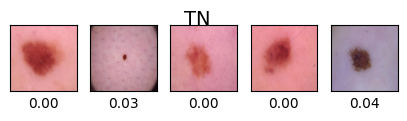

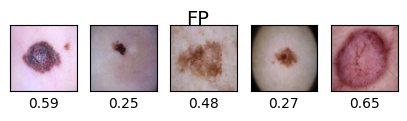

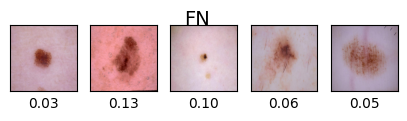

In [27]:
# Load ResNet50 model
final_resnet50_model = models.resnet50()
final_resnet50_model.fc = nn.Linear(final_resnet50_model.fc.in_features, 2)
final_resnet50_model = final_resnet50_model.to(device)

checkpoint_path = os.path.join(MODELS_FOLDER_PATH, "resnet50_melanoma_final.pth")
checkpoint = torch.load(checkpoint_path, map_location=device)
final_resnet50_model.load_state_dict(checkpoint['model_state_dict'])

resnet50_threshold = plot_precision_recall_curve(model=final_resnet50_model, val_loader=val_loader, device=device, target_recall=0.95)
Test_Model(final_resnet50_model, test_loader=test_loader, threshold=resnet50_threshold, show_efficiency=True, show_samples=True)

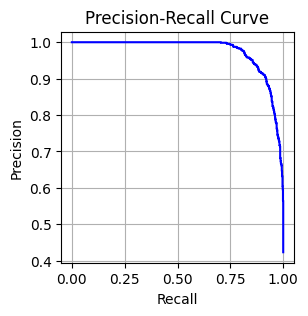

Testing: 100%|██████████| 67/67 [00:24<00:00,  2.75it/s]

Prediction threshold: 0.16896884143352509

Accuracy:  0.90657
Precision: 0.84615
Recall:    0.95228
F1-score:  0.89608
ROC AUC:   0.97987


,Pred Benign (0),Pred Malignant (1)
True Benign (0),1073,156
True Malignant (1),43,858



=== Model Efficiency ===
Inference time for 2130 images: 24.39 s
Average time per image: 11.45 ms
Throughput: 87.33 images/sec

Total parameters: 11,177,538
Model size: 42.64 MB
Peak GPU memory: 598.05 MB
FLOPs: 1.82 GFLOPs


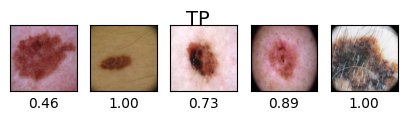

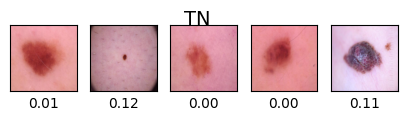

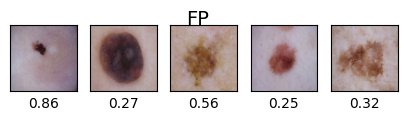

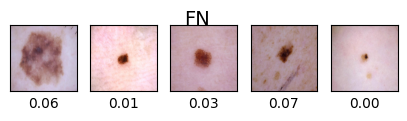

In [28]:
# Load ResNet18 model
final_resnet18_model = models.resnet18()
final_resnet18_model.fc = nn.Linear(final_resnet18_model.fc.in_features, 2)
final_resnet18_model = final_resnet18_model.to(device)

checkpoint_path = os.path.join(MODELS_FOLDER_PATH, "resnet18_melanoma_final.pth")
checkpoint = torch.load(checkpoint_path, map_location=device)
final_resnet18_model.load_state_dict(checkpoint['model_state_dict'])

resnet18_threshold = plot_precision_recall_curve(model=final_resnet18_model, val_loader=val_loader, device=device, target_recall=0.95)
Test_Model(final_resnet18_model, test_loader=test_loader, threshold=resnet18_threshold, show_efficiency=True, show_samples=True)

# Robustness Test
**Note:** Must run Load Dataset and Test Model first

In [ ]:
import torch
from torchvision import transforms

class NoiseTransform:
    def __init__(self, std=0.1):
        self.std = std

    def __call__(self, x):
        noise = torch.randn_like(x) * self.std
        x = torch.clamp(x + noise, 0.0, 1.0) # add noise, then clamp so pixel value is valid between 0-1
        return x

torch.manual_seed(42)

weak_noise_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    NoiseTransform(std=0.05),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

strong_noise_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    NoiseTransform(std=0.1),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


weak_noisy_test_loader = DataLoader(ImageDataset(path_test, y_test, transform=weak_noise_transform), batch_size=BATCH_SIZE, shuffle=False)
strong_noisy_test_loader = DataLoader(ImageDataset(path_test, y_test, transform=strong_noise_transform), batch_size=BATCH_SIZE, shuffle=False)

In [36]:
Test_Model(final_resnet50_model, test_loader=weak_noisy_test_loader, threshold=resnet50_threshold)
Test_Model(final_resnet50_model, test_loader=strong_noisy_test_loader, threshold=resnet50_threshold)

Testing: 100%|██████████| 67/67 [00:27<00:00,  2.47it/s]

Prediction threshold: 0.17190226912498474

Accuracy:  0.83146
Precision: 0.85286
Recall:    0.72697
F1-score:  0.78490
ROC AUC:   0.93134


,Pred Benign (0),Pred Malignant (1)
True Benign (0),1116,113
True Malignant (1),246,655


Testing: 100%|██████████| 67/67 [00:33<00:00,  1.98it/s]

Prediction threshold: 0.17190226912498474

Accuracy:  0.64836
Precision: 0.58389
Recall:    0.58713
F1-score:  0.58550
ROC AUC:   0.70193


,Pred Benign (0),Pred Malignant (1)
True Benign (0),852,377
True Malignant (1),372,529


In [37]:
Test_Model(final_resnet18_model, test_loader=weak_noisy_test_loader, threshold=resnet18_threshold)
Test_Model(final_resnet18_model, test_loader=strong_noisy_test_loader, threshold=resnet18_threshold)

Testing: 100%|██████████| 67/67 [00:36<00:00,  1.82it/s]

Prediction threshold: 0.16896884143352509

Accuracy:  0.85164
Precision: 0.89581
Recall:    0.73474
F1-score:  0.80732
ROC AUC:   0.94327


,Pred Benign (0),Pred Malignant (1)
True Benign (0),1152,77
True Malignant (1),239,662


Testing: 100%|██████████| 67/67 [00:36<00:00,  1.82it/s]

Prediction threshold: 0.16896884143352509

Accuracy:  0.81972
Precision: 0.88296
Recall:    0.66149
F1-score:  0.75635
ROC AUC:   0.90337


,Pred Benign (0),Pred Malignant (1)
True Benign (0),1150,79
True Malignant (1),305,596
